# Imports and Configuration

In [1]:
# Imports and Configuration
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import time
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
from tqdm import tqdm

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configuration
dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16
EPOCHS = 100  
PATIENCE = 10

print("Libraries imported and configuration set!")

2025-12-15 02:47:38.134875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765766858.158846     252 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765766858.165329     252 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries imported and configuration set!


# CBAM Attention Module

In [2]:
# CBAM Attention Module
class CBAM(keras.layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channel = input_shape[-1]
        
        # Channel Attention
        self.channel_avg_pool = layers.GlobalAveragePooling2D()
        self.channel_max_pool = layers.GlobalMaxPooling2D()
        self.channel_dense1 = layers.Dense(self.channel // self.reduction_ratio, 
                                          activation='relu', 
                                          kernel_initializer='he_normal')
        self.channel_dense2 = layers.Dense(self.channel, 
                                          kernel_initializer='he_normal')
        
        # Spatial Attention
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, 
                                         padding='same', 
                                         activation='sigmoid',
                                         kernel_initializer='he_normal')
        
        super(CBAM, self).build(input_shape)

    def call(self, inputs):
        # Channel Attention
        avg_pool = self.channel_avg_pool(inputs)
        max_pool = self.channel_max_pool(inputs)
        
        avg_out = self.channel_dense2(self.channel_dense1(avg_pool))
        max_out = self.channel_dense2(self.channel_dense1(max_pool))
        
        channel_attention = tf.sigmoid(avg_out + max_out)
        channel_attention = tf.reshape(channel_attention, [-1, 1, 1, self.channel])
        
        # Apply channel attention
        x = inputs * channel_attention
        
        # Spatial Attention
        avg_pool_spatial = tf.reduce_mean(x, axis=3, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=3, keepdims=True)
        spatial_attention = tf.concat([avg_pool_spatial, max_pool_spatial], axis=3)
        
        spatial_attention = self.spatial_conv(spatial_attention)
        
        # Apply spatial attention
        output = x * spatial_attention
        
        return output

    def get_config(self):
        config = super(CBAM, self).get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

print("CBAM Attention Module defined!")

CBAM Attention Module defined!


# Model Architecture

In [3]:
# Enhanced Model Architecture
def build_enhanced_attention_cnn_model():
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # Initial Convolution Block (matching PyTorch)
    x = layers.Conv2D(32, (7, 7), strides=2, padding='same', 
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # Residual Block 1 (64 channels)
    shortcut = x
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Apply CBAM attention
    x = CBAM(reduction_ratio=16)(x)
    
    # Adjust shortcut if needed
    if shortcut.shape[-1] != 64:
        shortcut = layers.Conv2D(64, (1, 1), padding='same', 
                                kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    
    # Residual Block 2 (128 channels) with stride
    shortcut = x
    x = layers.Conv2D(128, (3, 3), strides=2, padding='same', 
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Apply CBAM attention
    x = CBAM(reduction_ratio=16)(x)
    
    # Adjust shortcut
    shortcut = layers.Conv2D(128, (1, 1), strides=2, padding='same', 
                            kernel_initializer='he_normal')(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    
    # Residual Block 3 (256 channels) with stride
    shortcut = x
    x = layers.Conv2D(256, (3, 3), strides=2, padding='same', 
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Apply CBAM attention
    x = CBAM(reduction_ratio=16)(x)
    
    # Adjust shortcut
    shortcut = layers.Conv2D(256, (1, 1), strides=2, padding='same', 
                            kernel_initializer='he_normal')(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    
    # Residual Block 4 (512 channels) with stride
    shortcut = x
    x = layers.Conv2D(512, (3, 3), strides=2, padding='same', 
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Adjust shortcut
    shortcut = layers.Conv2D(512, (1, 1), strides=2, padding='same', 
                            kernel_initializer='he_normal')(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    
    # Global Pooling and Fully Connected Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.5)(x)
    
    # Output Layer
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Create and display model
print("\nBuilding Enhanced Attention CNN with Residual Connections...")
model = build_enhanced_attention_cnn_model()
model.summary()


Building Enhanced Attention CNN with Residual Connections...


I0000 00:00:1765766863.600878     252 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765766863.601496     252 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      4,736 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam (CBAM)         │ (None, 56, 56,    │        679 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ cbam[0][0],       │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     73,856 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ conv2d_5[0][0]  

 Total params: 5,440,597 (20.75 MB)

 Trainable params: 5,433,749 (20.73 MB)

 Non-trainable params: 6,848 (26.75 KB)

# Data Generators

In [4]:
# Data Preparation
print("\nPreparing data with 70/15/15 split...")

# Get all file paths and labels
image_paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))
            # Get label from directory name
            label = os.path.basename(root)
            labels.append(label)

# Convert to numpy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

# Convert string labels to indices
unique_labels = np.unique(labels)
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
indices = np.array([label_to_index[label] for label in labels])

# Split into train (70%), temp (30%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, indices, test_size=0.3, random_state=42, stratify=indices
)

# Split temp into validation (15%) and test (15%)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"\nData Split Summary:")
print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")

# Get class names for display
class_names = list(unique_labels)
print(f"\nClass names: {class_names}")
# Custom Data Generator
import tempfile
import shutil

def custom_data_generator(image_paths, labels, batch_size=32, augment=False):
    # Create augmentation pipeline
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=5,  
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,  
            zoom_range=0.0,  
            brightness_range=[0.9, 1.1]  
        )
    else:
        datagen = ImageDataGenerator(rescale=1./255)
    
    # Create temporary directory structure
    temp_dir = tempfile.mkdtemp()
    
    # Create class subdirectories
    for label_idx in range(NUM_CLASSES):
        os.makedirs(os.path.join(temp_dir, str(label_idx)), exist_ok=True)
    
    # Copy images to temporary directory
    for img_path, label in zip(image_paths, labels):
        label_dir = os.path.join(temp_dir, str(label))
        shutil.copy(img_path, label_dir)
    
    generator = datagen.flow_from_directory(
        temp_dir,
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=augment
    )
    
    # Clean up function
    def cleanup():
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
    
    # Register cleanup
    import atexit
    atexit.register(cleanup)
    
    return generator

# Create data generators
print("\nCreating data generators...")
train_gen = custom_data_generator(train_paths, train_labels, BATCH_SIZE, augment=True)
val_gen = custom_data_generator(val_paths, val_labels, BATCH_SIZE, augment=False)
test_gen = custom_data_generator(test_paths, test_labels, BATCH_SIZE, augment=False)

print(f"\nData Generators Created:")
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")


Preparing data with 70/15/15 split...

Data Split Summary:
Training samples: 2445
Validation samples: 524
Test samples: 525

Class names: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']

Creating data generators...
Found 2445 images belonging to 16 classes.
Found 524 images belonging to 16 classes.
Found 525 images belonging to 16 classes.

Data Generators Created:
Training samples: 2445
Validation samples: 524
Test samples: 525


# Class Weights

In [5]:
# Compute Class Weights
print("\nComputing class weights...")
train_labels_array = train_labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)
class_weights = dict(enumerate(class_weights))
print(f"Class weights: {class_weights}")



Computing class weights...
Class weights: {0: 1.0837765957446808, 1: 1.1236213235294117, 2: 0.5361842105263158, 3: 1.6256648936170213, 4: 1.4416273584905661, 5: 1.4149305555555556, 6: 2.010690789473684, 7: 0.955078125, 8: 1.3892045454545454, 9: 0.779655612244898, 10: 0.7418082524271845, 11: 1.591796875, 12: 0.7418082524271845, 13: 0.7917746113989638, 14: 0.9205572289156626, 15: 0.9205572289156626}


# Compile Model

In [6]:
# Compile Model
print("\nCompiling model...")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Learning rate: {model.optimizer.learning_rate.numpy()}")


Compiling model...
Model compiled successfully!
Learning rate: 0.0010000000474974513


# Setup Callbacks

In [7]:
# Setup Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',  
        factor=0.5,  
        patience=5,  
        min_lr=1e-6,  
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_attention_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
for i, callback in enumerate(callbacks, 1):
    print(f"{i}. {callback.__class__.__name__}")

Callbacks configured:
1. EarlyStopping
2. ReduceLROnPlateau
3. ModelCheckpoint


# Train Model

In [8]:
# Train Model
print("\nStarting training...")
print("=" * 50)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Class weights applied: Yes")
print("=" * 50)

start_time = time.time()

history = model.fit(
    train_gen,
    epochs=EPOCHS,  
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights,  
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Number of epochs trained: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")


Starting training...
Epochs: 100
Batch size: 32
Training samples: 2445
Validation samples: 524
Class weights applied: Yes


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1765766880.162447     306 service.cc:148] XLA service 0x7b406403e5d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765766880.162487     306 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765766880.162491     306 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765766881.799610     306 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/77 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.1250 - loss: 5.6989  

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 417ms/step - accuracy: 0.9812 - loss: 0.0527 - val_accuracy: 0.9676 - val_loss: 0.1190 - learning_rate: 2.5000e-04
Epoch 32/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9704 - loss: 0.0755
Epoch 32: val_accuracy did not improve from 0.96756
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 416ms/step - accuracy: 0.9704 - loss: 0.0755 - val_accuracy: 0.9103 - val_loss: 0.3009 - learning_rate: 2.5000e-04
Epoch 33/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9824 - loss: 0.0453
Epoch 33: val_accuracy did not improve from 0.96756
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 410ms/step - accuracy: 0.9824 - loss: 0.0454 - val_accuracy: 0.9427 - val_loss: 0.1747 - learning_rate: 2.5000e-04
Epoch 34/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9876 - loss: 0.0461
Epoch 34: val_accuracy did not improve from 0.96756
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 411ms/step - accuracy: 0.9876 - loss: 0.0462 - val_accuracy: 0.9504 - val_loss: 0.1362 - learning_rate: 2.5000e

77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 411ms/step - accuracy: 0.9852 - loss: 0.0441 - val_accuracy: 0.9809 - val_loss: 0.0552 - learning_rate: 1.2500e-04
Epoch 39/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9871 - loss: 0.0449
Epoch 39: val_accuracy did not improve from 0.98092
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 407ms/step - accuracy: 0.9871 - loss: 0.0449 - val_accuracy: 0.9676 - val_loss: 0.0862 - learning_rate: 1.2500e-04
Epoch 40/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9875 - loss: 0.0524
Epoch 40: val_accuracy did not improve from 0.98092
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 414ms/step - accuracy: 0.9875 - loss: 0.0524 - val_accuracy: 0.1508 - val_loss: 9.0029 - learning_rate: 1.2500e-04
Epoch 41/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9901 - loss: 0.0357
Epoch 41: val_accuracy did not improve from 0.98092
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 408ms/step - accuracy: 0.9901 - loss: 0.0358 - val_accuracy: 0.4332 - val_loss: 3.5495 - learning_rate: 1.2500e

77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 409ms/step - accuracy: 0.9902 - loss: 0.0333 - val_accuracy: 0.9962 - val_loss: 0.0123 - learning_rate: 1.2500e-04
Epoch 43/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9912 - loss: 0.0305
Epoch 43: val_accuracy did not improve from 0.99618
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 406ms/step - accuracy: 0.9912 - loss: 0.0305 - val_accuracy: 0.7920 - val_loss: 1.0509 - learning_rate: 1.2500e-04
Epoch 44/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9911 - loss: 0.0235
Epoch 44: val_accuracy did not improve from 0.99618
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 413ms/step - accuracy: 0.9911 - loss: 0.0235 - val_accuracy: 0.8760 - val_loss: 0.3764 - learning_rate: 1.2500e-04
Epoch 45/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9915 - loss: 0.0292
Epoch 45: val_accuracy did not improve from 0.99618
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 410ms/step - accuracy: 0.9914 - loss: 0.0293 - val_accuracy: 0.8244 - val_loss: 0.8230 - learning_rate: 1.2500e

77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 417ms/step - accuracy: 0.9927 - loss: 0.0203 - val_accuracy: 0.9981 - val_loss: 0.0099 - learning_rate: 6.2500e-05
Epoch 51/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9912 - loss: 0.0171
Epoch 51: val_accuracy did not improve from 0.99809
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 403ms/step - accuracy: 0.9912 - loss: 0.0171 - val_accuracy: 0.9924 - val_loss: 0.0260 - learning_rate: 6.2500e-05
Epoch 52/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9907 - loss: 0.0247
Epoch 52: val_accuracy did not improve from 0.99809
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 415ms/step - accuracy: 0.9907 - loss: 0.0248 - val_accuracy: 0.9981 - val_loss: 0.0085 - learning_rate: 6.2500e-05
Epoch 53/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9936 - loss: 0.0237
Epoch 53: val_accuracy did not improve from 0.99809
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 404ms/step - accuracy: 0.9936 - loss: 0.0237 - val_accuracy: 0.9885 - val_loss: 0.0259 - learning_rate: 6.2500e

77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 411ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 0.0023 - learning_rate: 3.1250e-05
Epoch 58/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9939 - loss: 0.0164
Epoch 58: val_accuracy did not improve from 1.00000
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 409ms/step - accuracy: 0.9939 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0035 - learning_rate: 3.1250e-05
Epoch 59/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9935 - loss: 0.0135
Epoch 59: val_accuracy did not improve from 1.00000
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 414ms/step - accuracy: 0.9935 - loss: 0.0136 - val_accuracy: 0.9885 - val_loss: 0.0262 - learning_rate: 3.1250e-05
Epoch 60/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9976 - loss: 0.0151
Epoch 60: val_accuracy did not improve from 1.00000
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 407ms/step - accuracy: 0.9976 - loss: 0.0151 - val_accuracy: 0.9962 - val_loss: 0.0152 - learning_rate: 3.1250e

# Model Evaluation

In [9]:
# Evaluate Model
def evaluate_model(model, test_gen, training_time):
    print("\n" + "="*60)
    print("MODEL EVALUATION ON TEST SET")
    print("="*60)
    
    # Predict on test set
    start_time = time.time()
    y_pred = model.predict(test_gen, verbose=1)
    testing_time = time.time() - start_time
    
    y_true = test_gen.classes
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_pred_proba = y_pred
    
    # Calculate metrics
    test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)
    
    # Classification report
    class_report = classification_report(y_true, y_pred_classes,
                                         target_names=class_names,
                                         output_dict=True)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # ROC Curve and AUC
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    
    # Calculate ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Calculate macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    
    return {
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'classification_report': class_report,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'macro_auc': macro_auc,
        'training_time': training_time,
        'testing_time': testing_time,
        'y_true': y_true,
        'y_pred_classes': y_pred_classes,
        'y_pred_proba': y_pred_proba
    }

# Evaluate the model on TEST set
results = evaluate_model(model, test_gen, training_time)

print(f"\nTest Accuracy: {results['test_accuracy']:.4f}")
print(f"Test Loss: {results['test_loss']:.4f}")
print(f"Macro-average AUC: {results['macro_auc']:.4f}")


MODEL EVALUATION ON TEST SET
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step

Test Accuracy: 1.0000
Test Loss: 0.0010
Macro-average AUC: 1.0000


# Training History Plot

Generating training history plot...


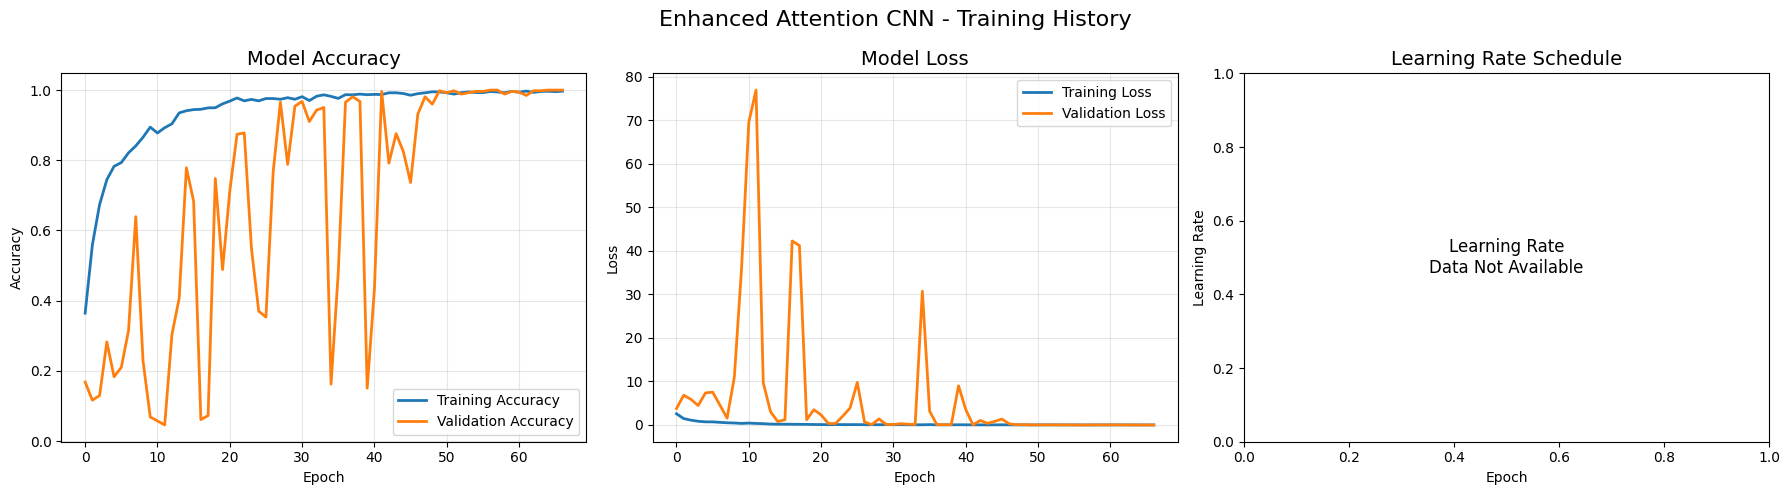

In [10]:
# Training History Plot
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot training & validation loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot learning rate if available
    if 'lr' in history.history:
        ax3.plot(history.history['lr'], label='Learning Rate', color='purple', linewidth=2)
        ax3.set_title('Learning Rate Schedule', fontsize=14)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')
        ax3.grid(True, alpha=0.3)
    else:
        # Create dummy plot
        ax3.text(0.5, 0.5, 'Learning Rate\nData Not Available', 
                ha='center', va='center', fontsize=12)
        ax3.set_title('Learning Rate Schedule', fontsize=14)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
    
    plt.suptitle('Enhanced Attention CNN - Training History', fontsize=16)
    plt.tight_layout()
    plt.show()

print("Generating training history plot...")
plot_training_history(history)

# Confusion Matrix

Generating confusion matrix...


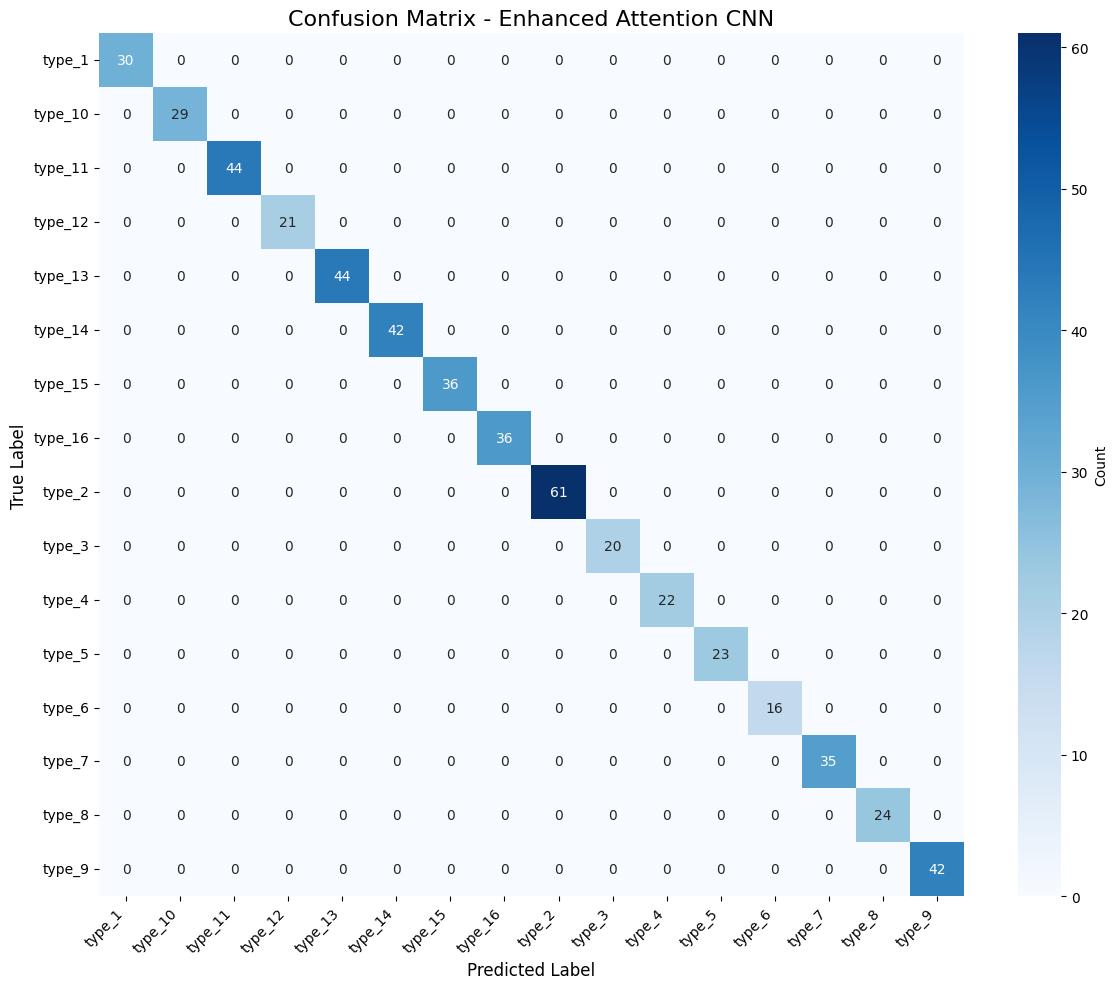

In [11]:

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Enhanced Attention CNN', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("Generating confusion matrix...")
plot_confusion_matrix(results['confusion_matrix'], class_names)

# ROC Curves

Generating ROC curves...


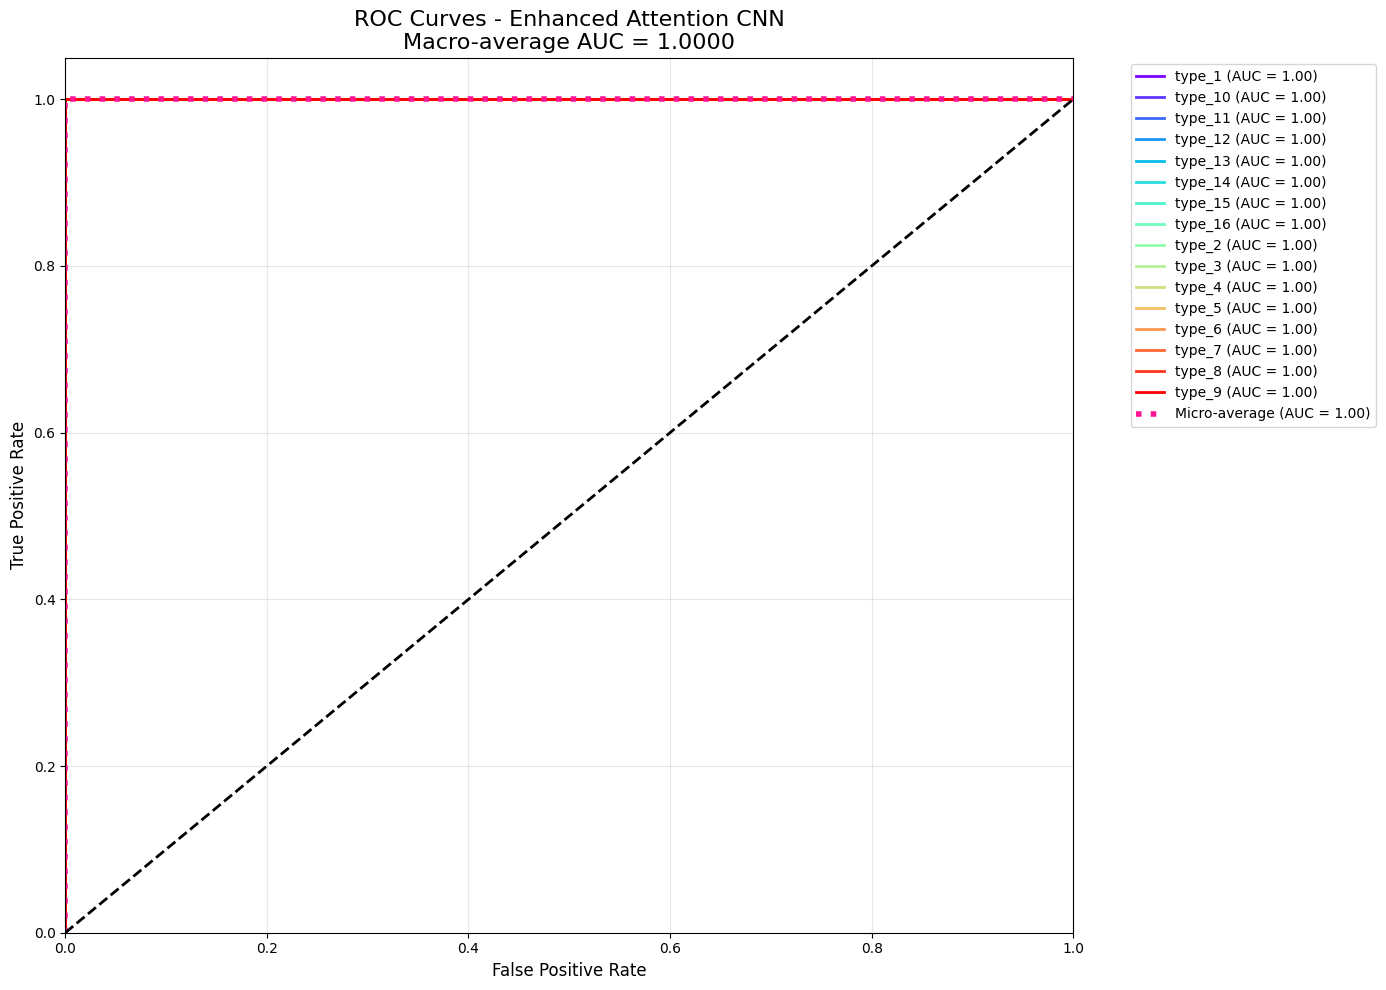

Micro-average AUC: 1.0000


In [12]:

def plot_roc_curve(fpr, tpr, roc_auc, macro_auc, class_names):
    plt.figure(figsize=(14, 10))
    
    colors = plt.cm.rainbow(np.linspace(0, 1, NUM_CLASSES))
    
    # Plot ROC curves for each class
    for i, color in zip(range(NUM_CLASSES), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    # Plot micro-average ROC curve
    y_true_bin = label_binarize(results['y_true'], classes=range(NUM_CLASSES))
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(),
                                        results['y_pred_proba'].ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', linewidth=4,
             label=f'Micro-average (AUC = {roc_auc_micro:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Enhanced Attention CNN\nMacro-average AUC = {0:.4f}'.format(macro_auc), fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return roc_auc_micro

print("Generating ROC curves...")
roc_auc_micro = plot_roc_curve(results['fpr'], results['tpr'], 
                               results['roc_auc'], results['macro_auc'], class_names)
print(f"Micro-average AUC: {roc_auc_micro:.4f}")

# Detailed Metrics Report

In [13]:
# Detailed Metrics
def print_detailed_metrics(results, class_names):
    print("\n" + "="*80)
    print("ENHANCED ATTENTION CNN - DETAILED METRICS")
    print("="*80)
    
    print(f"\nOverall Metrics:")
    print(f"  Test Accuracy: {results['test_accuracy']:.4f} ({results['test_accuracy']*100:.2f}%)")
    print(f"  Test Loss: {results['test_loss']:.4f}")
    print(f"  Macro-average AUC: {results['macro_auc']:.4f}")
    print(f"  Micro-average AUC: {roc_auc_micro:.4f}")
    print(f"  Training Time: {results['training_time']:.2f} seconds")
    print(f"  Testing Time: {results['testing_time']:.2f} seconds")
    
    print(f"\nClass-wise Performance:")
    print("-" * 70)
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10} {'Support':<10}")
    print("-" * 70)
    
    for i, class_name in enumerate(class_names):
        report = results['classification_report'][class_name]
        print(f"{class_name:<15} {report['precision']:<10.4f} {report['recall']:<10.4f} "
              f"{report['f1-score']:<10.4f} {results['roc_auc'][i]:<10.4f} {report['support']:<10}")
    
    print("-" * 70)
    
    # Macro averages
    macro_avg = results['classification_report']['macro avg']
    print(f"\nMacro Averages:")
    print(f"  Precision: {macro_avg['precision']:.4f}")
    print(f"  Recall: {macro_avg['recall']:.4f}")
    print(f"  F1-Score: {macro_avg['f1-score']:.4f}")

print_detailed_metrics(results, class_names)


ENHANCED ATTENTION CNN - DETAILED METRICS

Overall Metrics:
  Test Accuracy: 1.0000 (100.00%)
  Test Loss: 0.0010
  Macro-average AUC: 1.0000
  Micro-average AUC: 1.0000
  Training Time: 2167.86 seconds
  Testing Time: 5.13 seconds

Class-wise Performance:
----------------------------------------------------------------------
Class           Precision  Recall     F1-Score   AUC        Support   
----------------------------------------------------------------------
type_1          1.0000     1.0000     1.0000     1.0000     30        
type_10         1.0000     1.0000     1.0000     1.0000     29        
type_11         1.0000     1.0000     1.0000     1.0000     44        
type_12         1.0000     1.0000     1.0000     1.0000     21        
type_13         1.0000     1.0000     1.0000     1.0000     44        
type_14         1.0000     1.0000     1.0000     1.0000     42        
type_15         1.0000     1.0000     1.0000     1.0000     36        
type_16         1.0000     1.000

# Save Final Model and Results

In [14]:
# Save Results
print("\n" + "="*80)
print("SAVING FINAL RESULTS")
print("="*80)

# Save the model
model.save('enhanced_attention_model.keras')
print("✓ Model saved as 'enhanced_attention_model.keras'")

# Save results
import pickle
with open('enhanced_attention_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✓ Results saved as 'enhanced_attention_results.pkl'")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)
print("✓ Training history saved as 'training_history.csv'")

# Save configuration
config = {
    'dataset_path': dataset_path,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'class_weights': class_weights,
    'training_samples': train_gen.samples,
    'validation_samples': val_gen.samples,
    'test_samples': test_gen.samples,
    'test_accuracy': results['test_accuracy'],
    'test_loss': results['test_loss'],
    'macro_auc': results['macro_auc'],
    'micro_auc': roc_auc_micro,
    'training_time': results['training_time'],
    'testing_time': results['testing_time'],
    'model_params': model.count_params(),
    'epochs_trained': len(history.history['loss'])
}

config_df = pd.DataFrame([config])
config_df.to_csv('model_config.csv', index=False)
print("✓ Configuration saved as 'model_config.csv'")

print("\n" + "="*80)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*80)
print("""
Files created:
1. enhanced_attention_model.keras  - Trained model
2. enhanced_attention_results.pkl  - Evaluation results
3. training_history.csv           - Training history
4. model_config.csv              - Configuration
5. model_comparison.csv          - Comparison table
""")


SAVING FINAL RESULTS
✓ Model saved as 'enhanced_attention_model.keras'
✓ Results saved as 'enhanced_attention_results.pkl'
✓ Training history saved as 'training_history.csv'
✓ Configuration saved as 'model_config.csv'

ALL FILES SAVED SUCCESSFULLY!

Files created:
1. enhanced_attention_model.keras  - Trained model
2. enhanced_attention_results.pkl  - Evaluation results
3. training_history.csv           - Training history
4. model_config.csv              - Configuration
5. model_comparison.csv          - Comparison table

